In [59]:
import numpy as np
import matplotlib.pyplot as plt 
import tensorflow as tf
from tensorflow import keras
%matplotlib inline

In [60]:
(X_train,y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [61]:
len(X_train)

60000

In [62]:
len(X_test)

10000

In [63]:
X_train[0].shape

(28, 28)

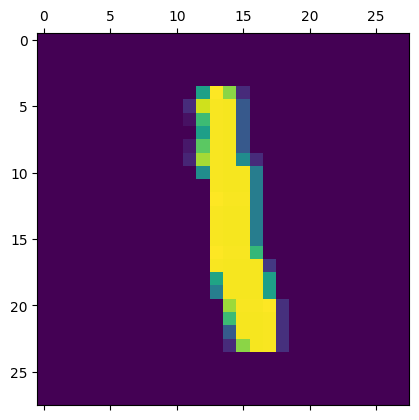

In [64]:
plt.matshow(X_train[6])

In [65]:
y_train[6]

np.uint8(1)

In [66]:
X_train = X_train / 255
X_test = X_test / 255

In [67]:
X_train_flattened = X_train.reshape(len(X_train), 28 * 28)
X_test_flattened = X_test.reshape(len(X_test), 28 * 28)
X_train_flattened.shape

(60000, 784)

In [68]:
X_test_flattened.shape

(10000, 784)

# Simple Neural Network

In [69]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape = (784,), activation = 'sigmoid')
])

model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.fit(X_train_flattened, y_train, epochs = 5)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8785 - loss: 0.4669
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9152 - loss: 0.3039
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9206 - loss: 0.2838
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9233 - loss: 0.2730
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9258 - loss: 0.2664


In [70]:
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9258 - loss: 0.2663


[0.26625820994377136, 0.9258000254631042]

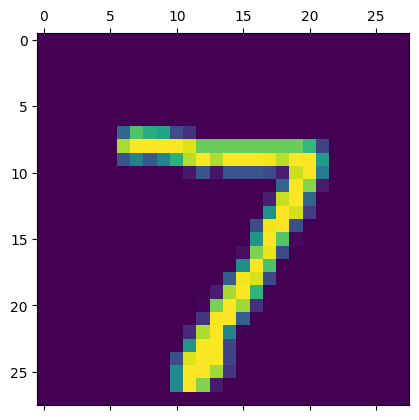

In [71]:
plt.matshow(X_test[0])

In [72]:
y_predicted = model.predict(X_test_flattened)
y_predicted[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([1.7391587e-02, 3.4356108e-07, 6.4216226e-02, 9.5999062e-01,
       3.6512325e-03, 1.5841539e-01, 1.4137290e-06, 9.9983215e-01,
       1.0211325e-01, 6.9834042e-01], dtype=float32)

In [73]:
np.argmax(y_predicted[0]) # Index of the highest value 

np.int64(7)

In [77]:
y_predicted_labels = [np.argmax(i) for i in y_predicted] #* y_predicted is a vector of probabilities (or scores) for                                                      #*each class
y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [78]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [80]:
cm = tf.math.confusion_matrix(labels = y_test, predictions = y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 960,    0,    2,    1,    0,    4,    9,    3,    1,    0],
       [   0, 1109,    3,    2,    0,    2,    4,    2,   13,    0],
       [   4,    8,  925,   17,    9,    5,   13,   10,   39,    2],
       [   2,    0,   19,  913,    1,   33,    3,   11,   21,    7],
       [   2,    1,    2,    1,  922,    0,   12,    4,    9,   29],
       [   7,    2,    2,   27,    9,  792,   15,    5,   26,    7],
       [   7,    3,    7,    1,    7,   14,  915,    2,    2,    0],
       [   1,    5,   24,    8,    9,    1,    0,  949,    3,   28],
       [   6,    6,    6,   22,    9,   37,   10,   13,  860,    5],
       [  10,    7,    2,   10,   29,    9,    0,   24,    5,  913]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'True')

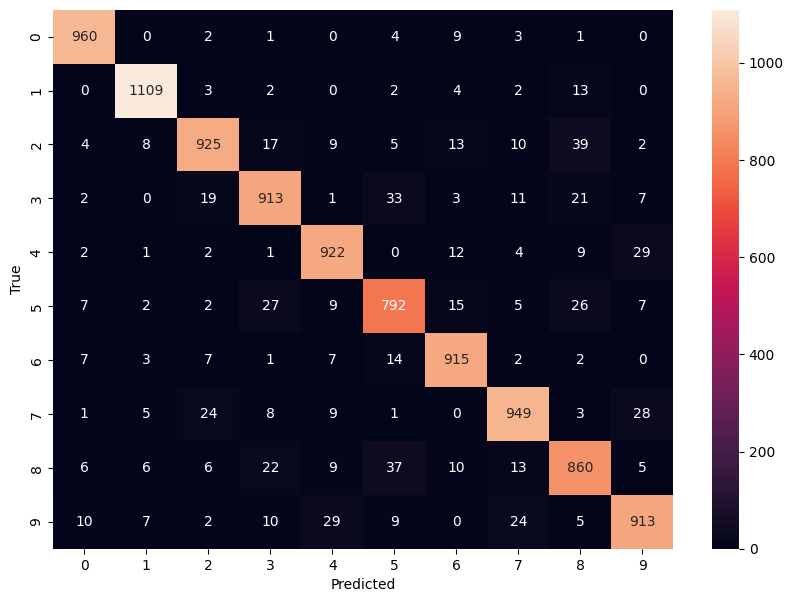

In [81]:
import seaborn as sns
plt.figure(figsize=(10,7)) 
sns.heatmap(cm, annot = True, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('True')

# Hidden layer is added 

In [83]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape = (784,), activation = 'relu'),
    keras.layers.Dense(10, activation = 'sigmoid')
])

model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.fit(X_train_flattened, y_train, epochs = 5)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9222 - loss: 0.2716
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9624 - loss: 0.1247
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9740 - loss: 0.0873
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9787 - loss: 0.0671
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9831 - loss: 0.0537


In [84]:
model.evaluate(X_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9769 - loss: 0.0746


[0.07459113746881485, 0.9768999814987183]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Text(95.72222222222221, 0.5, 'True')

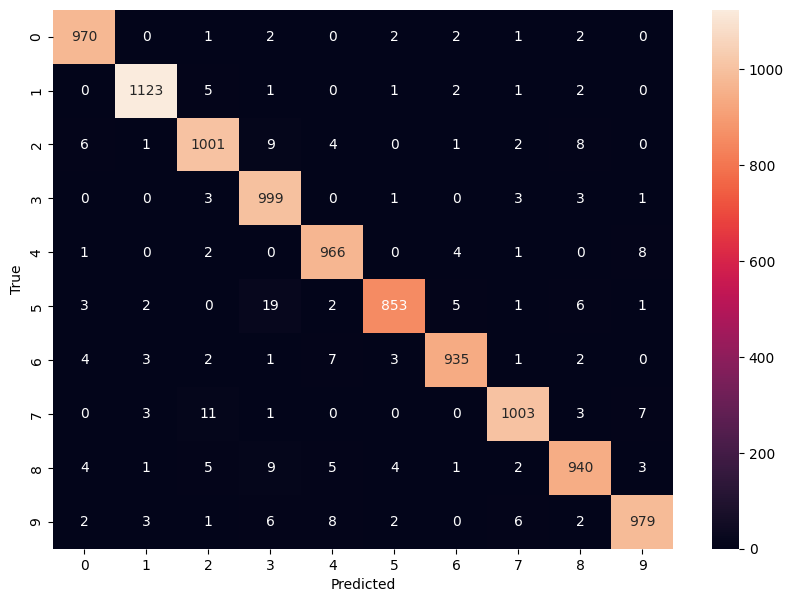

In [ ]:
y_predicted = model.predict(X_test_flattened)
y_predicted_labels = [np.argmax(i) for i in y_predicted] 

cm = tf.math.confusion_matrix(labels = y_test, predictions = y_predicted_labels)

import seaborn as sns
plt.figure(figsize=(10,7)) 
sns.heatmap(cm, annot = True, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('True')